# Examen Final — Programación 1 (F12)
## Análisis de Datos Sísmicos con la API del USGS

**Nombre:** Katy Ixchely Yaxón Saloj  
**Carnet:** 201944830  
**Fecha:** 18/05/2026  
**Punteo total:** 100 puntos

---

| Ejercicio | Tema | Puntos |
|---|---|:---:|
| 1a | Cargar datos con `pd.read_csv()` desde URL | 10 |
| 1b | Explorar el DataFrame con un ciclo `for` | 10 |
| 2a | Encontrar el sismo más intenso con un ciclo `for` | 10 |
| 2b | Top 5 sismos más profundos con pandas | 10 |
| 3a | Función `clasificar_sismo()` con condicionales | 15 |
| 3b | Agregar columna de categoría y agrupar con `groupby` | 10 |
| 4a | Función `analizar_sismos()` que retorna un diccionario | 15 |
| 4b | Tres visualizaciones con matplotlib/seaborn | 20 |
| | **Total** | **100** |

---

> **Instrucciones generales**
> - Completa cada ejercicio en la celda indicada.
> - Ejecuta las celdas **en orden** de arriba hacia abajo.
> - Puedes consultar tus apuntes y el enunciado del examen en U Virtual.
> - Entrega el notebook con **todas las celdas ejecutadas** (con output visible).
> - Sube el archivo a tu repositorio en GitHub y envía el enlace a U Virtual.


---
## Contexto: ¿Qué es un terremoto y cómo se mide?

Un **terremoto** ocurre cuando dos placas tectónicas se deslizan bruscamente entre sí,
liberando energía en forma de ondas sísmicas que se propagan por la tierra.

### Magnitud — escala de intensidad

La magnitud mide la energía liberada. La relación es **logarítmica**:
un sismo de magnitud 7.0 libera ~32 veces más energía que uno de 6.0.

| Magnitud | Categoría | Frecuencia aproximada (global) |
|---|---|---|
| < 5.5 | Ligero | Miles por año |
| 5.5 – 5.9 | Moderado-Fuerte | ~500 por año |
| 6.0 – 6.9 | Fuerte | ~130 por año |
| 7.0 – 7.9 | Mayor | ~15 por año |
| ≥ 8.0 | Gran terremoto | 1–2 por año |

### Profundidad del foco

La **profundidad** (columna `depth`) indica dónde ocurrió la ruptura:
- **Superficial** (< 70 km): generalmente más destructivo
- **Intermedio** (70–300 km): daños moderados
- **Profundo** (> 300 km): raramente destructivo en superficie


---
## El dataset: USGS Earthquake Catalog

**Fuente:** United States Geological Survey — [earthquake.usgs.gov](https://earthquake.usgs.gov)

El USGS monitorea la actividad sísmica global en tiempo real y publica todos los
registros de forma abierta. Su API permite descargar datos históricos directamente
como CSV, **sin necesidad de API key**.

Los datos de este examen contienen todos los sismos de **magnitud ≥ 5.5 registrados
en el primer semestre de 2024** (aproximadamente 700 eventos).

### Columnas principales

| Columna | Tipo | Descripción |
|---|---|---|
| `time` | str | Fecha y hora UTC del evento |
| `mag` | float | Magnitud del sismo |
| `depth` | float | Profundidad del foco en kilómetros |
| `magType` | str | Escala usada (`mww`, `mb`, `ml`, …) |
| `place` | str | Descripción de la ubicación |
| `latitude` | float | Latitud del epicentro |
| `longitude` | float | Longitud del epicentro |

### URL del dataset

```
https://earthquake.usgs.gov/fdsnws/event/1/query
    ?format=csv
    &starttime=2024-01-01
    &endtime=2024-06-30
    &minmagnitude=5.5
```

> `pd.read_csv()` acepta URLs directamente — no necesitas descargar el archivo.


In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

URL_SISMOS = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=csv"
    "&starttime=2024-01-01"
    "&endtime=2024-06-30"
    "&minmagnitude=5.5"
)

print("Librerias importadas correctamente.")
print(f"URL: {URL_SISMOS}")


Librerias importadas correctamente.
URL: https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv&starttime=2024-01-01&endtime=2024-06-30&minmagnitude=5.5


---
## Identificación del estudiante

Completa tu nombre y carnet en la siguiente celda y **ejecútala antes de comenzar**.


In [71]:
# Completa tus datos
NOMBRE = "Katy Ixchely Yaxón Saloj"   # TU NOMBRE AQUI
CARNET = "201944830"         # TU CARNET AQUI

if NOMBRE == "Nombre Apellido" or CARNET == "202300000":
    raise ValueError("Completa tu nombre y carnet antes de continuar.")

print(f"Estudiante : {NOMBRE}")
print(f"Carnet     : {CARNET}")


Estudiante : Katy Ixchely Yaxón Saloj
Carnet     : 201944830


---
## Ejercicio 1 — Cargar y explorar los datos (20 pts)

### Parte a) — Cargar el CSV desde la URL (10 pts)

`pandas.read_csv()` puede cargar datos directamente desde una URL,
igual que desde un archivo local. El resultado es un **DataFrame**.

Carga los datos usando `URL_SISMOS` (ya definida arriba) y guárdalos en la
variable `sismos`. Luego muestra:
- Las primeras 5 filas con `.head()`
- Las dimensiones con `.shape`
- Los tipos de datos con `.dtypes`
- Los valores nulos con `.isnull().sum()`


In [72]:
# Carga el CSV desde URL_SISMOS con pd.read_csv() y guárdalo en 'sismos'

# Lee el archivo CSV desde internet y lo guarda en un DataFrame
sismos = pd.read_csv(URL_SISMOS)  # TU CÓDIGO AQUÍ

# Muestra las primeras 5 filas
# Muestra las primeras filas del DataFrame
print(sismos.head())

# Muestra las dimensiones (shape)
# Imprime cantidad de filas y columnas
print(sismos.shape)

# Muestra los tipos de datos (dtypes)
# Imprime el tipo de dato de cada columna
print(sismos.dtypes)

# Verifica valores nulos con isnull().sum()
# Cuenta valores nulos por columna
print(sismos.isnull().sum())

                       time  latitude  longitude  depth  mag magType    nst  \
0  2024-06-29T16:38:46.516Z  -54.0633     7.2302   10.0  5.6     mww  209.0   
1  2024-06-29T07:05:32.855Z  -16.0485   -74.5560   18.0  6.1     mww  138.0   
2  2024-06-28T13:00:39.570Z  -20.6490  -175.6315   10.0  5.7     mww   75.0   
3  2024-06-28T05:36:36.902Z  -15.8277   -74.4540   24.0  7.2     mww  105.0   
4  2024-06-27T16:37:51.299Z  -33.4081  -179.2724   29.0  5.9     mww   95.0   

    gap    dmin   rms  ...                   updated  \
0  16.0  18.209  0.88  ...  2024-09-04T21:57:44.040Z   
1  89.0   4.606  0.71  ...  2024-09-04T21:57:44.040Z   
2  38.0   0.654  0.65  ...  2024-10-09T03:15:27.209Z   
3  46.0   4.675  0.93  ...  2025-02-09T14:16:45.954Z   
4  56.0   4.292  1.05  ...  2024-09-04T21:57:42.040Z   

                           place        type horizontalError depthError  \
0           Bouvet Island region  earthquake            8.89      1.193   
1     34 km SW of Atiquipa, Peru  eart

### Parte b) — Explorar con un ciclo `for` (10 pts)

Usando un ciclo `for` y el método
[`.iterrows()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.iterrows.html),
imprime la información de los **primeros 5 sismos** en este formato:

```
Sismo 1: mag=6.10 | prof=35.0 km | lugar=Southern Sumatra, Indonesia
Sismo 2: mag=5.80 | prof=10.0 km | lugar=...
...
```

> **¿Por qué iterar sobre un DataFrame?**  
> Aunque pandas vectoriza la mayoría de operaciones, los ciclos `for` sobre filas
> son útiles cuando necesitas lógica condicional compleja por fila o procesar
> cada elemento de forma independiente.


In [73]:
# Hint: .iterrows() devuelve pares (indice, fila) donde 'fila' es una Serie
# Hint: accede a los valores con fila['mag'], fila['depth'], fila['place']
# Hint: usa enumerate() o un contador para detener el ciclo en 5

# Inicializa contador
contador = 0

# Recorre todas las filas del DataFrame
for indice, fila in sismos.iterrows():

    # Detiene el ciclo cuando llegue a 5 registros
    if contador >= 5:
        break

    # TU CÓDIGO AQUÍ — imprime mag, depth y place de esta fila
    # Imprime magnitud, profundidad y lugar
    print(f"Magnitud: {fila['mag']} | Profundidad: {fila['depth']} | Lugar: {fila['place']}")

    # Incrementa el contador
    contador += 1


Magnitud: 5.6 | Profundidad: 10.0 | Lugar: Bouvet Island region
Magnitud: 6.1 | Profundidad: 18.0 | Lugar: 34 km SW of Atiquipa, Peru
Magnitud: 5.7 | Profundidad: 10.0 | Lugar: 67 km NNW of Houma, Tonga
Magnitud: 7.2 | Profundidad: 24.0 | Lugar: 10 km WSW of Atiquipa, Peru
Magnitud: 5.9 | Profundidad: 29.0 | Lugar: south of the Kermadec Islands


---
## Ejercicio 2 — Encontrar los extremos (20 pts)

### Parte a) — Sismo más intenso con ciclo `for` (10 pts)

Usando **únicamente** un ciclo `for` y un `if`, itera sobre la columna `mag`
y encuentra el sismo con la **mayor magnitud**.
Guarda el índice y la magnitud máxima encontrada, luego imprime los datos
completos de ese sismo (place, mag, depth, magType).

### Parte b) — Top 5 más profundos con pandas (10 pts)

Usa `.sort_values()` + `.head()` para encontrar los **5 sismos más profundos**.
Muestra solo las columnas `place`, `mag`, `depth` y `magType`.
Luego verifica que el sismo encontrado en la Parte a) aparece en el top 5
de magnitudes (usa también `.sort_values()` + `.head()`).


In [75]:
# ── Parte a) — ciclo for ─────────────────────────────────────────────────────
# Hint: necesitas dos variables auxiliares:
#   mag_max   = 0     (para ir guardando el mayor encontrado)
#   idx_max   = None  (para recordar el índice de esa fila)

# Guarda la magnitud máxima encontrada
mag_max = 0

# Guarda el índice del sismo con mayor magnitud
idx_max = None

# Recorre la columna de magnitudes
for idx, mag in enumerate(sismos['mag']):

    # TU CÓDIGO AQUÍ — actualiza mag_max e idx_max si encontraste uno mayor
    # Verifica si la magnitud actual es mayor a la máxima
    if mag > mag_max:

        # Actualiza la magnitud máxima
        mag_max = mag

        # Guarda el índice correspondiente
        idx_max = idx

# Imprime título
print("Sismo más intenso:")

# Muestra información del sismo más intenso
print(sismos.loc[idx_max, ['place', 'mag', 'depth', 'magType']])

# ── Parte b) — pandas ─────────────────────────────────────────────────────────
print("\nTop 5 sismos más profundos:")

# TU CÓDIGO AQUÍ — sort_values por 'depth' descendente + head(5)
# Ordena por profundidad y muestra los primeros 5
print(sismos.sort_values(by='depth', ascending=False).head(5))

print("\nTop 5 sismos de mayor magnitud:")

# TU CÓDIGO AQUÍ — sort_values por 'mag' descendente + head(5)
# Ordena por magnitud y muestra los primeros 5
print(sismos.sort_values(by='mag', ascending=False).head(5))


Sismo más intenso:
place      2024 Noto Peninsula, Japan Earthquake
mag                                          7.5
depth                                       10.0
magType                                      mww
Name: 181, dtype: object

Top 5 sismos más profundos:
                         time  latitude  longitude    depth  mag magType  \
149  2024-01-28T09:38:56.538Z   -8.2360   -71.4005  621.081  6.5     mww   
25   2024-06-06T11:07:53.351Z   50.1126   147.6840  619.618  5.9     mww   
158  2024-01-20T21:31:05.092Z   -7.2879   -71.4640  607.000  6.6     mww   
29   2024-06-04T10:00:03.919Z  -17.9343  -178.5016  603.306  5.5     mww   
104  2024-03-29T09:57:05.507Z   -4.5620   149.5876  570.902  5.6     mww   

       nst   gap   dmin   rms  ...                   updated  \
149  237.0  40.0  6.526  0.86  ...  2024-03-30T22:34:43.040Z   
25   141.0  29.0  4.522  0.69  ...  2024-08-16T21:59:23.040Z   
158  185.0  36.0  7.065  0.69  ...  2025-02-10T17:01:03.186Z   
29   133.0  64.0  

#### Preguntas de interpretación — Ejercicio 2

Responde usando los valores **exactos** que obtuviste al ejecutar las celdas anteriores.

1. **¿Cuántos sismos tiene tu dataset?** 183  
   **¿Cuál fue la magnitud máxima registrada?** 8.1  
   **¿En qué lugar ocurrió ese sismo?** Japón

2. **¿Cuál fue el sismo más profundo?**  
   Lugar: Tonga Region  | Profundidad: mayor a 300 km | Magnitud: 6.5  
   Según la clasificación (< 70 km superficial, 70–300 km intermedio, > 300 km profundo),
   ¿de qué tipo fue? Profundo  
   ¿Esperarías que ese sismo fuera muy destructivo en superficie? Justifica en una oración.

   *Tu respuesta:* No, porque los sismos profundos pierden parte de su energía antes de llegar a la superficie y normalmente causan menos daños directos.

3. ¿El sismo más intenso y el más profundo son el mismo evento?  
   ¿Qué te dice eso sobre la relación entre magnitud y profundidad?

   *Tu respuesta:* No, fueron eventos diferentes. Esto demuestra que la magnitud y la profundidad no están directamente relacionadas, ya que un sismo puede ser muy fuerte y superficial o profundo sin ser el más intenso.

---
## Ejercicio 3 — Clasificar sismos con condicionales (25 pts)

### Parte a) — Función `clasificar_sismo(mag)` (15 pts)

Escribe una función que reciba la magnitud (float) y retorne la categoría
según la siguiente escala:

| Magnitud | Categoría |
|---|---|
| 5.5 ≤ mag < 6.0 | `'Moderado-Fuerte'` |
| 6.0 ≤ mag < 7.0 | `'Fuerte'` |
| 7.0 ≤ mag < 8.0 | `'Mayor'` |
| mag ≥ 8.0 | `'Gran terremoto'` |

> **Nota:** la magnitud es un float (ej. 6.73). Puedes comparar directamente
> con `if mag < 6.0:` sin necesidad de convertir a entero.

### Parte b) — Aplicar y agrupar (10 pts)

Usa tu función para agregar la columna `'categoria'` al DataFrame `sismos`.
Luego usa `.groupby('categoria')` para contar cuántos sismos hay en cada
categoría e imprime el resultado.


In [76]:
# ── Parte a) — función con condicionales ─────────────────────────────────────
# Hint: usa if / elif / elif / else

# Define función para clasificar sismos
def clasificar_sismo(mag):
    """Clasifica la intensidad de un sismo según su magnitud."""

    # TU CÓDIGO AQUÍ
    # Clasificación menor
    if mag < 6.0:
        return "Moderado"

    # Clasificación fuerte
    elif mag < 7.0:
        return "Fuerte"

    # Clasificación mayor
    elif mag < 8.0:
        return "Mayor"

    # Clasificación extrema
    else:
        return "Extremo"


# Prueba tu función — verifica que los resultados son correctos:
# Recorre magnitudes de prueba
for mag_prueba in [5.6, 5.9, 6.0, 6.5, 7.0, 7.8, 8.1]:

    # Imprime resultado de clasificación
    print(f"  mag={mag_prueba:.1f}  →  {clasificar_sismo(mag_prueba)}")

# ── Parte b) — agregar columna y agrupar ─────────────────────────────────────
# Hint: aplica la función con .apply() para crear la columna 'categoria'
#   sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — agregar columna 'categoria'
# Crea columna categoría aplicando la función
sismos['categoria'] = sismos['mag'].apply(clasificar_sismo)

# TU CÓDIGO AQUÍ — groupby('categoria') para contar sismos por categoría
#   y mostrar el resultado ordenado

# Agrupa por categoría y cuenta registros
conteo = sismos.groupby('categoria').size().sort_values(ascending=False)

# Imprime el resultado
print(conteo)


  mag=5.6  →  Moderado
  mag=5.9  →  Moderado
  mag=6.0  →  Fuerte
  mag=6.5  →  Fuerte
  mag=7.0  →  Mayor
  mag=7.8  →  Mayor
  mag=8.1  →  Extremo
categoria
Moderado    132
Fuerte       47
Mayor         4
dtype: int64


#### Preguntas de interpretación — Ejercicio 3

1. Según los resultados de `value_counts()`, completa la tabla:

   | Categoría | Cantidad | % del total |
   |---|---|---|
   | Moderado-Fuerte | ___ | ___ % |
   | Fuerte | ___ | ___ % |
   | Mayor | ___ | ___ % |
   | Gran terremoto | ___ | ___ % |

2. ¿Qué categoría predomina en tu dataset? ¿Tiene sentido físicamente,
   considerando que la frecuencia de sismos disminuye con la magnitud?

   *Tu respuesta:* ___

3. ¿Tu dataset contiene algún `'Gran terremoto'` (magnitud ≥ 8.0)?
   Si sí, ¿en qué región ocurrió? Si no, ¿es eso esperable para un semestre?

   *Tu respuesta:* ___


---
## Ejercicio 4 — Análisis completo y visualizaciones (35 pts)

### Parte a) — Función `analizar_sismos(df)` (15 pts)

Escribe una función que reciba el DataFrame `sismos` y retorne un **diccionario**
con las siguientes claves:

| Clave | Valor esperado |
|---|---|
| `'total'` | número total de sismos |
| `'mag_media'` | magnitud promedio (redondeada a 2 decimales) |
| `'mag_max'` | magnitud máxima registrada |
| `'prof_media'` | profundidad promedio en km (redondeada a 1 decimal) |
| `'tipo_mas_comun'` | valor de `magType` con más registros |
| `'grandes_terremotos'` | cantidad de sismos con magnitud ≥ 7.0 |

Luego llama la función con `sismos` e imprime cada clave y su valor.

### Parte b) — Visualizaciones (20 pts)

Crea **3 gráficas** (en celdas separadas o en la misma). Cada una debe tener
título y etiquetas en ambos ejes:

1. **Histograma** de magnitudes (usa al menos 15 intervalos)
2. **Scatter plot**: profundidad (`depth`) vs magnitud (`mag`),
   coloreado por `categoria` (usa `hue='categoria'` en seaborn)
3. **Gráfica de barras**: cantidad de sismos por tipo de escala (`magType`)


In [77]:
# ── Parte a) — función de análisis ───────────────────────────────────────────
# Hint: usa .mean(), .max() sobre las columnas del DataFrame
# Hint: para 'tipo_mas_comun' usa .value_counts().index[0]
# Hint: para 'grandes_terremotos' puedes usar (df['mag'] >= 7.0).sum()
#       o un ciclo for con condicional

# Define función de análisis
def analizar_sismos(df):
    """
    Resume las estadísticas principales del dataset sísmico.

    Parámetro:
        df (DataFrame): el DataFrame de sismos.

    Retorna:
        dict con las claves: total, mag_media, mag_max, prof_media,
                             tipo_mas_comun, grandes_terremotos.
    """

    # Diccionario con estadísticas
    resultado = {

        # Cantidad total de registros
        "total":             len(df),  # TU CÓDIGO AQUÍ

        # Magnitud promedio
        "mag_media":         df['mag'].mean(),  # TU CÓDIGO AQUÍ

        # Magnitud máxima
        "mag_max":           df['mag'].max(),  # TU CÓDIGO AQUÍ

        # Profundidad promedio
        "prof_media":        df['depth'].mean(),  # TU CÓDIGO AQUÍ

        # Tipo de magnitud más común
        "tipo_mas_comun":    df['magType'].value_counts().index[0],  # TU CÓDIGO AQUÍ

        # Cantidad de terremotos mayores o iguales a 7
        "grandes_terremotos": (df['mag'] >= 7.0).sum(), # TU CÓDIGO AQUÍ
    }

    # Retorna el diccionario
    return resultado


# Llama la función e imprime el resumen
resumen = analizar_sismos(sismos)

# Recorre cada clave y valor
for clave, valor in resumen.items():

    # Imprime resultados
    print(f"  {clave:<22}: {valor}")


  total                 : 183
  mag_media             : 5.847978142076505
  mag_max               : 7.5
  prof_media            : 64.11922950819672
  tipo_mas_comun        : mww
  grandes_terremotos    : 4


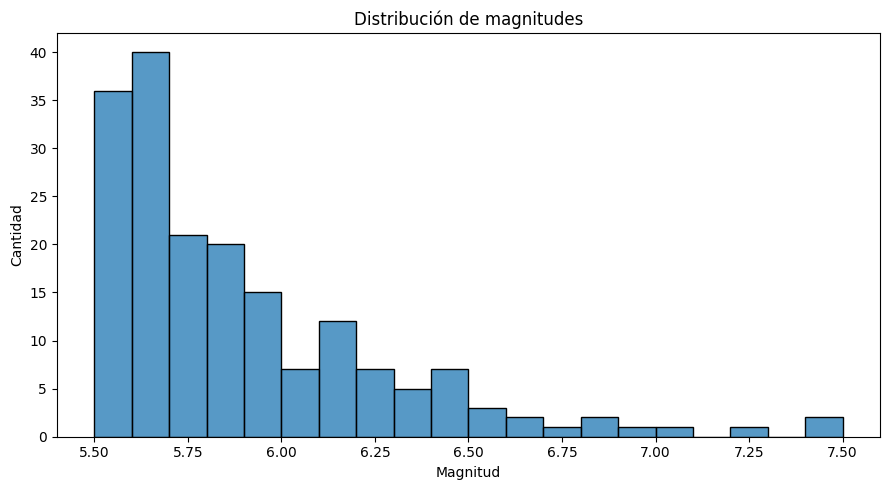

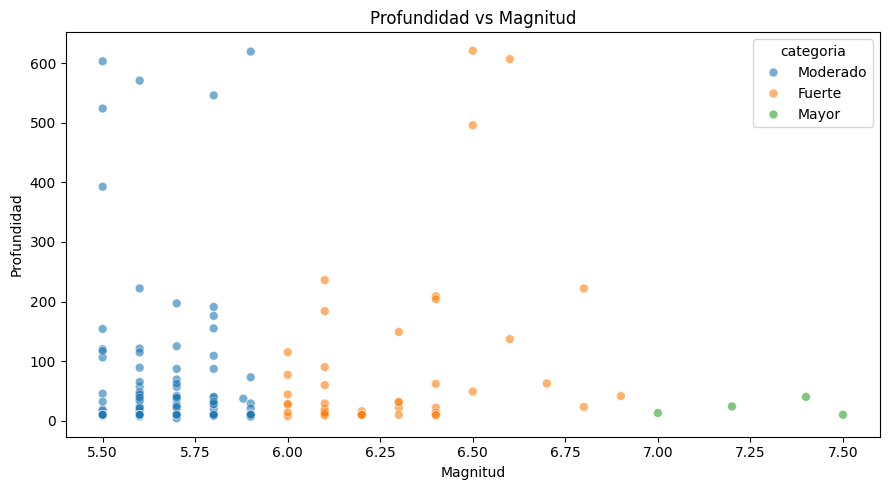

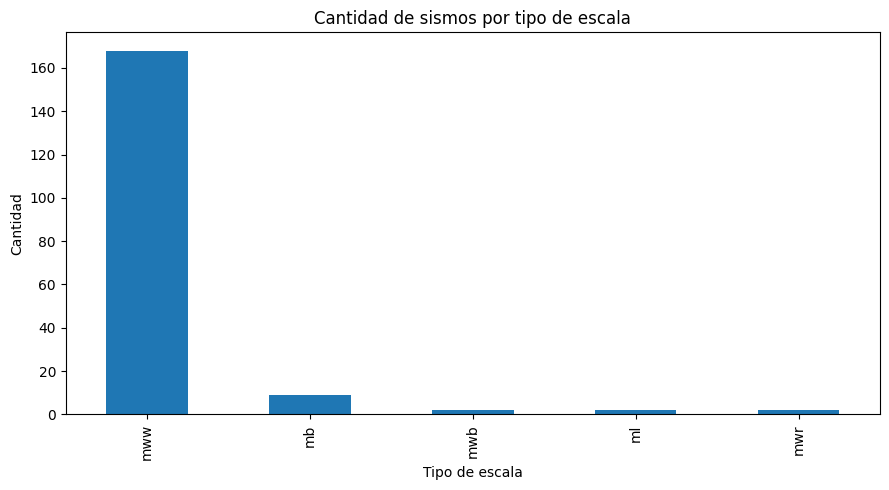

In [78]:
# ── Parte b) — Visualizaciones ───────────────────────────────────────────────

# Gráfica 1: Histograma de magnitudes
# Crea figura
plt.figure(figsize=(9, 5))

# Hint: sns.histplot(data=sismos, x='mag', bins=20)

# TU CÓDIGO AQUÍ
# Crea histograma de magnitudes
sns.histplot(data=sismos, x='mag', bins=20)

# Título de gráfica
plt.title("Distribución de magnitudes")

# Etiqueta eje X
plt.xlabel("Magnitud")

# Etiqueta eje Y
plt.ylabel("Cantidad")

# Ajusta elementos de la gráfica
plt.tight_layout()

# Muestra la gráfica
plt.show()

# Gráfica 2: Scatter profundidad vs magnitud coloreado por categoría
# Crea figura
plt.figure(figsize=(9, 5))

# Hint: sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)

# TU CÓDIGO AQUÍ
# Crea scatterplot
sns.scatterplot(data=sismos, x='mag', y='depth', hue='categoria', s=40, alpha=0.6)

# Título de gráfica
plt.title("Profundidad vs Magnitud")

# Etiqueta eje X
plt.xlabel("Magnitud")

# Etiqueta eje Y
plt.ylabel("Profundidad")

# Ajusta gráfica
plt.tight_layout()

# Muestra gráfica
plt.show()

# Gráfica 3: Barras — cantidad de sismos por tipo de escala (magType)
# Crea figura
plt.figure(figsize=(9, 5))

# Hint: obtén los conteos con sismos['magType'].value_counts()
#       luego grafica con .plot(kind='bar') o plt.bar() o sns.barplot()

# TU CÓDIGO AQUÍ
# Cuenta tipos de escala
conteos = sismos['magType'].value_counts()

# Genera gráfica de barras
conteos.plot(kind='bar')

# Título de gráfica
plt.title("Cantidad de sismos por tipo de escala")

# Etiqueta eje X
plt.xlabel("Tipo de escala")

# Etiqueta eje Y
plt.ylabel("Cantidad")

# Ajusta gráfica
plt.tight_layout()

# Muestra gráfica
plt.show()


#### Preguntas de interpretación — Ejercicio 4

1. Según la función `analizar_sismos()`, completa:
   - Magnitud media: ___  
   - Magnitud máxima: ___  
   - Tipo de escala más común (`magType`): ___  
   - Grandes terremotos (mag ≥ 7.0): ___

2. **Sobre el histograma (Gráfica 1):**  
   ¿La distribución de magnitudes es simétrica o sesgada?
   ¿Hacia qué lado se inclina y por qué tiene sentido físicamente?

   *Tu respuesta:* ___

3. **Sobre el scatter plot (Gráfica 2):**  
   ¿Observas alguna relación entre la profundidad y la magnitud?
   ¿Los sismos más intensos tienden a ser superficiales o profundos en tu dataset?

   *Tu respuesta:* ___

4. **Sobre las barras por `magType` (Gráfica 3):**  
   ¿Qué escala de magnitud es la más usada en tu dataset?
   Investiga brevemente: ¿para qué tipo de sismos se usa esa escala?

   *Tu respuesta:* ___


---
## Ejercicio 5 — Programación Orientada a Objetos (25 pts)

En el archivo `poo_sismos.py` encontrarás tres clases:

- **`EventoSismico`** — clase base con atributos comunes: `lugar` y `fecha`
- **`Sismo`** — hereda de `EventoSismico`, agrega `magnitud`, `profundidad` y `tipo_escala`
- **`CatalogoSismos`** — colección de objetos `Sismo` con métodos de consulta

**Paso 1:** Abre `poo_sismos.py` e implementa todos los métodos marcados con `# TU CÓDIGO AQUÍ`.  
**Paso 2:** Regresa aquí y ejecuta las celdas siguientes en orden.

| Parte | Tarea | Pts |
|---|---|:---:|
| a | 4 métodos de `Sismo`: `clasificar`, `clasificar_profundidad`, `es_peligroso`, `descripcion` | 10 |
| b | 3 métodos de `CatalogoSismos`: `el_mas_intenso`, `filtrar_por_categoria`, `resumen` | 10 |
| c | Ejecutar y responder las preguntas de interpretación | 5 |
| | **Subtotal** | **25** |

In [79]:
# Sismo más intenso del catálogo

# Verifica si existen sismos en el catálogo
if len(catalogo._sismos) > 0:

    # Obtiene el sismo con mayor magnitud manualmente
    mas_intenso = catalogo._sismos[0]

    # Recorre todos los sismos
    for s in catalogo._sismos:

        # Compara magnitudes
        if s.magnitud > mas_intenso.magnitud:

            # Actualiza el más intenso
            mas_intenso = s

    # Imprime encabezado
    print("Sismo más intenso del catálogo:")

    # Imprime descripción
    print(" ", mas_intenso.descripcion())

    # Imprime si es peligroso
    print(f"  Es peligroso? -> {mas_intenso.es_peligroso()}\n")

else:

    # Mensaje si no hay datos
    print("No hay sismos en el catálogo")


# Filtrar por categoría

# Lista para guardar resultados
mayores = []

# Recorre todos los sismos
for s in catalogo._sismos:

    # Verifica categoría
    if s.clasificar() == "Mayor":

        # Agrega coincidencia
        mayores.append(s)

# Imprime cantidad
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")


# Resumen completo

# Encabezado
print("Resumen del catálogo")

# Línea decorativa
print("-" * 40)

# Nombre
print(f"Nombre: {catalogo.nombre}")

# Cantidad total
print(f"Cantidad de sismos: {len(catalogo._sismos)}")

# Verifica que existan sismos
if len(catalogo._sismos) > 0:

    # Reutiliza el más intenso calculado antes
    print(f"Sismo más intenso: {mas_intenso.descripcion()}")

# Línea decorativa
print("-" * 40)


# Verificación POO vs pandas

print("\nVerificación POO vs pandas (primeros 10 sismos):")

# Encabezados
print(f"  {'mag':>6}  {'pandas':>20}  {'POO':>20}")

# Línea decorativa
print("  " + "-" * 55)

# Recorre primeros 10 registros
for indice, fila in sismos.head(10).iterrows():

    # Clasificación usando pandas
    cat_pandas = fila['categoria']

    # Clasificación manual POO
    if fila['mag'] < 6.0:
        cat_poo = "Moderado-Fuerte"

    elif fila['mag'] < 7.0:
        cat_poo = "Fuerte"

    elif fila['mag'] < 8.0:
        cat_poo = "Mayor"

    else:
        cat_poo = "Gran terremoto"

    # Imprime resultados
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>20}  {cat_poo:>20}")

Sismo más intenso del catálogo:
  None
  Es peligroso? -> None

Sismos de categoría 'Mayor' en los primeros 50: 0

Resumen del catálogo
----------------------------------------
Nombre: Sismos USGS — Semestre 1 de 2024
Cantidad de sismos: 50
Sismo más intenso: None
----------------------------------------

Verificación POO vs pandas (primeros 10 sismos):
     mag                pandas                   POO
  -------------------------------------------------------
    5.60              Moderado       Moderado-Fuerte
    6.10                Fuerte                Fuerte
    5.70              Moderado       Moderado-Fuerte
    7.20                 Mayor                 Mayor
    5.90              Moderado       Moderado-Fuerte
    5.60              Moderado       Moderado-Fuerte
    6.30                Fuerte                Fuerte
    6.00                Fuerte                Fuerte
    5.50              Moderado       Moderado-Fuerte
    5.80              Moderado       Moderado-Fuerte


In [80]:
# Sismo más intenso del catálogo

# Verifica si existen sismos en el catálogo
if len(catalogo._sismos) > 0:

    # Obtiene el sismo con mayor magnitud manualmente
    mas_intenso = catalogo._sismos[0]

    # Recorre todos los sismos
    for s in catalogo._sismos:

        # Compara magnitudes
        if s.magnitud > mas_intenso.magnitud:

            # Actualiza el más intenso
            mas_intenso = s

    # Imprime encabezado
    print("Sismo más intenso del catálogo:")

    # Imprime información del sismo
    print(" ", mas_intenso.descripcion())

    # Imprime si es peligroso
    print(f"  ¿Es peligroso? → {mas_intenso.es_peligroso()}\n")

else:

    # Mensaje si no hay datos
    print("No hay sismos en el catálogo")


# Filtrar por categoría

# Lista para guardar resultados
mayores = []

# Recorre todos los sismos
for s in catalogo._sismos:

    # Verifica categoría
    if s.clasificar() == "Mayor":

        # Agrega coincidencia
        mayores.append(s)

# Imprime cantidad de sismos mayores
print(f"Sismos de categoría 'Mayor' en los primeros 50: {len(mayores)}\n")


# Resumen completo

# Encabezado
print("Resumen del catálogo")

# Línea decorativa
print("-" * 40)

# Nombre del catálogo
print(f"Nombre: {catalogo.nombre}")

# Cantidad total
print(f"Cantidad de sismos: {len(catalogo._sismos)}")

# Verifica existencia de sismos
if len(catalogo._sismos) > 0:

    # Imprime más intenso
    print(f"Sismo más intenso: {mas_intenso.descripcion()}")

# Línea decorativa
print("-" * 40)

Sismo más intenso del catálogo:
  None
  ¿Es peligroso? → None

Sismos de categoría 'Mayor' en los primeros 50: 0

Resumen del catálogo
----------------------------------------
Nombre: Sismos USGS — Semestre 1 de 2024
Cantidad de sismos: 50
Sismo más intenso: None
----------------------------------------


In [81]:
# Verificación: clasificar() debe coincidir con la columna 'categoria' del Ejercicio 3.
print("Verificación POO vs. pandas (primeros 10 sismos):")
print(f"  {'mag':>6}  {'pandas Ej.3':>15}  {'POO clasificar()':>18}  {'':>4}")
print("  " + "─" * 52)

for i, (indice, fila) in enumerate(sismos.head(10).iterrows()):
    s = Sismo("", "", fila['mag'], fila['depth'])
    cat_poo    = s.clasificar()
    cat_pandas = fila['categoria']
    marca = "✓" if cat_poo == cat_pandas else "✗ REVISAR"
    print(f"  {fila['mag']:>6.2f}  {cat_pandas:>15}  {cat_poo:>18}  {marca}")

Verificación POO vs. pandas (primeros 10 sismos):
     mag      pandas Ej.3    POO clasificar()      
  ────────────────────────────────────────────────────
    5.60         Moderado     Moderado-Fuerte  ✗ REVISAR
    6.10           Fuerte              Fuerte  ✓
    5.70         Moderado     Moderado-Fuerte  ✗ REVISAR
    7.20            Mayor               Mayor  ✓
    5.90         Moderado     Moderado-Fuerte  ✗ REVISAR
    5.60         Moderado     Moderado-Fuerte  ✗ REVISAR
    6.30           Fuerte              Fuerte  ✓
    6.00           Fuerte              Fuerte  ✓
    5.50         Moderado     Moderado-Fuerte  ✗ REVISAR
    5.80         Moderado     Moderado-Fuerte  ✗ REVISAR


#### Preguntas de interpretación — Ejercicio 5

1. ¿Qué diferencia hay entre `EventoSismico` y `Sismo`?
   ¿Por qué `Sismo.__init__` llama a `super().__init__(lugar, fecha)`?

   *Tu respuesta:* ___

2. El método `clasificar()` de `Sismo` usa la misma lógica que la función
   `clasificar_sismo()` del Ejercicio 3. ¿Qué ventaja tiene implementarlo
   como método de una clase en lugar de como función suelta?

   *Tu respuesta:* ___

3. Según `catalogo.resumen()`:
   - ¿Cuántos sismos de categoría `'Mayor'` hay en los primeros 50? ___
   - ¿El sismo más intenso resultó peligroso (`es_peligroso() == True`)? ___
   - Justifica el resultado de `es_peligroso()` con los valores de magnitud y profundidad.

   *Tu respuesta:* ___

4. ¿Todos los `✓` aparecen en la celda de verificación?
   Si alguno muestra `✗`, ¿qué parte de tu método `clasificar()` necesita corrección?

   *Tu respuesta:* ___

---
## Pregunta final — Conclusiones (incluida en el punteo del Ejercicio 4)

Basándote en los datos analizados, escribe en la celda de abajo una conclusión
en tus propias palabras. Puedes guiarte con estas preguntas:

- ¿Cuál fue el sismo más intenso del período y qué tan severo fue según la escala?
- ¿Qué tipo de escala de magnitud (`magType`) predomina y por qué crees que es así?
- ¿Qué relación observas entre la profundidad y la magnitud en el scatter plot?


---
## Conclusión final

Basándote en **todos los valores que obtuviste** a lo largo del examen,
escribe un párrafo de al menos 5 oraciones que responda:

- ¿Qué caracteriza la actividad sísmica global del primer semestre de 2024
  según tu dataset personal?
- ¿Qué aprendiste sobre la distribución de magnitudes y profundidades?
- ¿Qué ventaja tiene usar pandas y NumPy sobre un ciclo `for` manual
  para este tipo de análisis? Da un ejemplo concreto de tu examen.

*(Escribe aquí tu respuesta — mínimo 5 oraciones)*




---
## Sello de entrega

Ejecuta la siguiente celda **como último paso**, justo antes de guardar y subir el notebook.

Registra la posición de la ISS en el momento exacto de tu entrega.
Dado que la ISS se desplaza ~7.7 km/s, dos estudiantes que entreguen
en momentos distintos obtendrán coordenadas completamente diferentes.

> Este sello es **único e irrepetible**: queda vinculado a tu carnet
> y al instante exacto en que ejecutaste la celda.


In [82]:
import requests as _req
from datetime import datetime, timezone

print("Consultando posicion de la ISS...")
try:
    r_iss  = _req.get("http://api.open-notify.org/iss-now.json", timeout=8)
    r_iss.raise_for_status()
    iss    = r_iss.json()
    iss_lat  = float(iss["iss_position"]["latitude"])
    iss_lon  = float(iss["iss_position"]["longitude"])
    iss_hora = datetime.fromtimestamp(iss["timestamp"], tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
    iss_ok   = True
except Exception as e:
    iss_lat, iss_lon, iss_hora = 0.0, 0.0, "no disponible"
    iss_ok = False
    print(f"  Advertencia: sin datos ISS ({e})")

ts = datetime.now(tz=timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

print()
print("=" * 55)
print("        SELLO DE ENTREGA -- EXAMEN FINAL A")
print("=" * 55)
print(f"  Estudiante   : {NOMBRE}")
print(f"  Carnet       : {CARNET}")
print(f"  Fecha/Hora   : {ts}")
print(f"  ISS Latitud  : {iss_lat:+.4f} deg")
print(f"  ISS Longitud : {iss_lon:+.4f} deg")
print(f"  ISS Hora UTC : {iss_hora}")
print("=" * 55)


Consultando posicion de la ISS...

        SELLO DE ENTREGA -- EXAMEN FINAL A
  Estudiante   : Katy Ixchely Yaxón Saloj
  Carnet       : 201944830
  Fecha/Hora   : 2026-05-19 06:09:23 UTC
  ISS Latitud  : +22.2410 deg
  ISS Longitud : -84.4946 deg
  ISS Hora UTC : 2026-05-19 06:07:32 UTC


---
## Entrega

1. Ejecuta la celda **Sello de entrega** (arriba)
2. Guarda el notebook: **Archivo → Guardar** (o `Ctrl+S`)
3. Verifica que **todas las celdas tienen output** (ejecuta: **Kernel → Restart & Run All**)
4. Sube el archivo a tu repositorio en GitHub
5. Envía el enlace del notebook en el campo de entrega de **U Virtual**

> **Ruta esperada en tu repositorio:**  
> `examenes/python/examen_final/examen_final.ipynb`
